In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False

帕累托分析（贡献度分析） → 帕累托法则：20/80定律

“原因和结果、投入和产出、努力和报酬之间本来存在着无法解释的不平衡。一般来说，投入和努力可以分为两种不同的类型：
多数，它们只能造成少许的影响；少数，它们造成主要的、重大的影响。”
→ 一个公司，80%利润来自于20%的畅销产品，而其他80%的产品只产生了20%的利润

例如：

    世界上大约80％的资源是由世界上15％的人口所耗尽的
    世界财富的80％为25％的人所拥有；在一个国家的医疗体系中
    20％的人口与20％的疾病，会消耗80％的医疗资源

一个思路：通过二八原则，去寻找关键的那20%决定性因素！

### 帕累托分布分析 

In [2]:
# 创建数据，10个品类产品的销售额
data = pd.Series(np.random.randn(10)*1200+3000,
                index = list('ABCDEFGHIJ'))
print(data)

A    2831.552157
B    2410.110053
C    1650.396830
D    4274.098232
E    3684.038541
F    3450.869287
G    2093.139648
H    4001.587098
I    3825.543076
J    2835.244484
dtype: float64


In [3]:
# 由大到小排列
data.sort_values(ascending=False, inplace= True)

In [4]:
#创建营收柱状图
p = data.cumsum()/data.sum() 
p

D    0.137623
H    0.266471
I    0.389651
E    0.508274
F    0.619390
J    0.710683
A    0.801857
B    0.879461
G    0.946858
C    1.000000
dtype: float64

In [5]:
# 找到累计占比超过80%时候的index
# 找到key所对应的索引位置

key = p[p>0.8].index[0]  
key

'A'

In [8]:
data.index.tolist()

['D', 'H', 'I', 'E', 'F', 'J', 'A', 'B', 'G', 'C']

In [7]:
key_num = data.index.tolist().index(key) 
key_num

6

In [ ]:
key_num = data.index.tolist().index(key) 
print('超过80%累计占比的节点值索引为：' ,key)
print('超过80%累计占比的节点值索引位置为：' ,key_num)

Text(6.2, 0.8018569124752579, '累计占比为：80.186%')

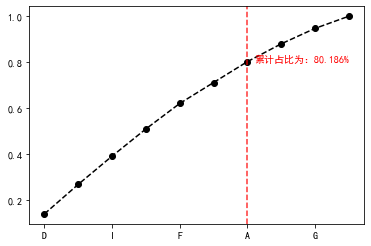

In [11]:
# p为应收的数据
p.plot(style = '--ko')
plt.axvline(key_num,color='r',linestyle="--",alpha=0.8)  
plt.text(key_num+0.2,p[key],'累计占比为：%.3f%%' % (p[key]*100), color = 'r')  # 累计占比超过80%的节点

In [ ]:
# 绘制营收累计占比曲线
p.plot(style = '--ko', secondary_y=True)  # secondary_y → y副坐标轴
# axvline 绘制垂直的线条
plt.axvline(key_num,color='r',linestyle="--",alpha=0.8)  

plt.text(key_num+0.2,p[key],'累计占比为：%.3f%%' % (p[key]*100), color = 'r')  # 累计占比超过80%的节点
plt.ylabel('营收_比例')

In [12]:
# 输出决定性因素产品
key_product = data.loc[:key]
print('核心产品为：')
print(key_product)

核心产品为：
D    4274.098232
H    4001.587098
I    3825.543076
E    3684.038541
F    3450.869287
J    2835.244484
A    2831.552157
dtype: float64
